In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import yfinance as yf

# Phase 0

## day 1 week 2

In [2]:
data = pd.read_csv('Nifty 50 Historical Data.csv')
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,20-07-2026,"24,238.50","24,190.05","24,264.60","24,136.85",353.10M,-0.39%
1,17-07-2026,"24,334.30","24,127.60","24,367.30","24,099.05",387.77M,1.09%
2,16-07-2026,"24,072.75","24,142.10","24,186.50","24,050.00",264.27M,-0.02%
3,15-07-2026,"24,078.50","24,085.85","24,220.35","24,010.55",306.92M,0.11%
4,14-07-2026,"24,052.05","24,068.00","24,157.10","24,023.70",355.83M,-0.66%


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      1239 non-null   str  
 1   Price     1239 non-null   str  
 2   Open      1239 non-null   str  
 3   High      1239 non-null   str  
 4   Low       1239 non-null   str  
 5   Vol.      1235 non-null   str  
 6   Change %  1239 non-null   str  
dtypes: str(7)
memory usage: 67.9 KB


In [4]:
data.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        4
Change %    0
dtype: int64

In [5]:
data[data.isnull().any(axis=1)]

,Date,Price,Open,High,Low,Vol.,Change %
597,19-02-2024,"22,122.25","22,103.45","22,186.65","22,021.05",NaN,0.37%
616,20-01-2024,"21,571.80","21,706.15","21,720.30","21,541.80",NaN,-0.23%
822,22-03-2023,"17,151.90","17,177.45","17,207.25","17,107.85",NaN,0.26%
972,16-08-2022,"17,825.25","17,797.20","17,839.10","17,764.05",NaN,0.72%


In [6]:
data.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,1239,1239,1239,1239,1239,1235,1239
unique,1239,1234,1237,1234,1238,1210,349
top,20-07-2026,"25,910.05","19,784.00","24,087.45","17,774.25",338.22M,0.14%
freq,1,2,2,2,2,2,13


In [7]:
datatypes = data.dtypes
datatypes

Date        str
Price       str
Open        str
High        str
Low         str
Vol.        str
Change %    str
dtype: object

In [8]:
# Strip the 'M' from the string
data['Vol.'] = data['Vol.'].str.replace('M', '', regex=False)
data['Vol.'] = data['Vol.'].str.replace('B', '', regex=False)
# Convert to float
data['Vol.'] = data['Vol.'].astype(float)

In [9]:
mean_vol = data['Vol.'].mean()
data['Vol.'] = data['Vol.'].fillna(mean_vol)

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1239 non-null   str    
 1   Price     1239 non-null   str    
 2   Open      1239 non-null   str    
 3   High      1239 non-null   str    
 4   Low       1239 non-null   str    
 5   Vol.      1239 non-null   float64
 6   Change %  1239 non-null   str    
dtypes: float64(1), str(6)
memory usage: 67.9 KB


In [11]:
data['Change %'] = data['Change %'].str.replace('%', '', regex=False)
data['Change %'] = data['Change %'].astype(float)

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1239 non-null   str    
 1   Price     1239 non-null   str    
 2   Open      1239 non-null   str    
 3   High      1239 non-null   str    
 4   Low       1239 non-null   str    
 5   Vol.      1239 non-null   float64
 6   Change %  1239 non-null   float64
dtypes: float64(2), str(5)
memory usage: 67.9 KB


In [13]:
count = (abs(data['Change %']) > 2).sum()
count

np.int64(39)

## day 2 week 2

In [14]:
data['Price'] = data['Price'].str.replace(',', '', regex=False).astype(float)

In [15]:
log_returns = np.log(data['Price'] / data['Price'].shift(1))
log_returns = log_returns.dropna() # removes the first NaN value
log_returns.head()

1    0.003945
2   -0.010806
3    0.000239
4   -0.001099
5    0.006587
Name: Price, dtype: float64

In [16]:
# adding log returns, rolling mean 20, 50 to data
data['Log Returns'] = log_returns
data['MA20'] = data['Price'].rolling(window=20).mean()
data['MA50'] = data['Price'].rolling(window=50).mean()
data.tail()


,Date,Price,Open,High,Low,Vol.,Change %,Log Returns,MA20,MA50
1234,27-07-2021,15746.45,"15,860.50","15,881.55","15,701.00",311.01,-0.49,0.002356,16241.8500,16944.990
1235,26-07-2021,15824.45,"15,849.30","15,893.35","15,797.00",267.08,-0.20,0.004941,16201.8425,16908.559
1236,23-07-2021,15856.05,"15,856.80","15,899.80","15,768.40",294.10,0.20,0.001995,16169.8225,16869.234
1237,22-07-2021,15824.05,"15,736.60","15,834.80","15,726.40",265.25,1.23,-0.002020,16138.5000,16831.890
1238,20-07-2021,15632.10,"15,703.95","15,728.45","15,578.55",274.28,-0.76,-0.012204,16091.6625,16793.891


In [17]:
volatility = data['Log Returns'].rolling(window = 20).std()* np.sqrt(252)
volatility.tail()
volatility.mean()


np.float64(0.12927875946575834)

## week 2 day 3

In [32]:
ticker = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'WIPRO.NS']
raw_data =  yf.download(ticker, period = '1y', interval = '1d')
raw_data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                     \
Ticker     HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS   
Date                                                                        
2025-07-29  994.353943  1459.297974  1404.966797  2934.193359  242.691040   
2025-07-30  996.419800  1464.407715  1398.026733  2931.888916  241.148911   
2025-07-31  992.681580  1454.767090  1378.296997  2915.758545  239.317657   
2025-08-01  989.730408  1416.782959  1381.767090  2883.305908  233.968430   
2025-08-04  979.794739  1427.291260  1399.414673  2951.859863  237.149048   

Price             High                                                     \
Ticker     HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS   
Date                                                                        
2025-07-29  996.764093  1462.672185  1408.040231  2951.475912  243.558476   
2025-07-30  999.764445  1467.010631  1411.113788  2946.675005  243.365710   
2025-07-31  999.174231  1472.216559  1390.590852  2937.841805  241.100724   
2025-08-01  997.649480  1444.837089  1393.862706  2915.758749  237.968296   
2025-08-04  992.829157  1429.508646  1403.975263  2956.660572  237.505658   

Price       ...        Open                                         \
Ticker      ... HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date        ...                                                      
2025-07-29  ...  983.680500  1458.526796  1371.158785  2938.033927   
2025-07-30  ...  997.501878  1465.275393  1405.958238  2938.033729   
2025-07-31  ...  990.910878  1455.441885  1376.215002  2920.463146   
2025-08-01  ...  990.615788  1440.209671  1375.025384  2909.133630   
2025-08-04  ...  988.697480  1408.974114  1383.155066  2889.162791   

Price                       Volume                                          
Ticker        WIPRO.NS HDFCBANK.NS  INFY.NS RELIANCE.NS   TCS.NS  WIPRO.NS  
Date                                                                        
2025-07-29  240.185090    19895696  7070448    10750072  4785312  12923128  
2025-07-30  242.353691    15154036  5719051     7209849  2880121   6057152  
2025-07-31  239.124895    22183032  6851407    17065827  2968371   7338764  
2025-08-01  237.582772    11317258  8702978    10321171  2053847   7436999  
2025-08-04  233.968424    13933946  8610216     6312820  2519252   5234393  

[5 rows x 25 columns]

In [33]:
close_data = raw_data['Close']
close_data.head()

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Date,,,,,
2025-07-29,994.353943,1459.297974,1404.966797,2934.193359,242.691040
2025-07-30,996.419800,1464.407715,1398.026733,2931.888916,241.148911
2025-07-31,992.681580,1454.767090,1378.296997,2915.758545,239.317657
2025-08-01,989.730408,1416.782959,1381.767090,2883.305908,233.968430
2025-08-04,979.794739,1427.291260,1399.414673,2951.859863,237.149048


In [34]:
close_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 250 entries, 2025-07-29 to 2026-07-29
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   HDFCBANK.NS  249 non-null    float64
 1   INFY.NS      249 non-null    float64
 2   RELIANCE.NS  249 non-null    float64
 3   TCS.NS       249 non-null    float64
 4   WIPRO.NS     249 non-null    float64
dtypes: float64(5)
memory usage: 11.7 KB


In [35]:
correlation = close_data.corr()
correlation

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.842387,0.690123,0.896813,0.875689
INFY.NS,0.842387,1.000000,0.747403,0.973643,0.943361
RELIANCE.NS,0.690123,0.747403,1.000000,0.741039,0.729098
TCS.NS,0.896813,0.973643,0.741039,1.000000,0.971147
WIPRO.NS,0.875689,0.943361,0.729098,0.971147,1.000000


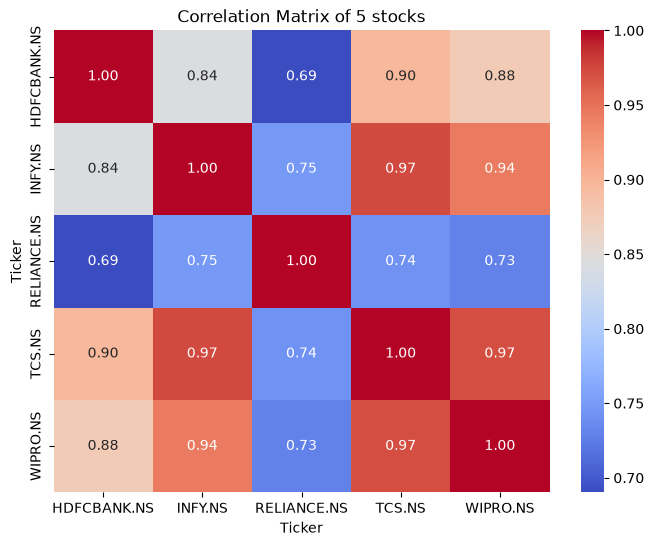

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of 5 stocks')
plt.show()

## week 2 day 4

**Portfolio Variance**: Calculated as $w^T \Sigma w$, where $w$ is the array of asset weights and $\Sigma$ (Sigma) is the covariance matrix of the asset returns. You take the square root of this variance to get the portfolio's volatility ($\sigma_p$).

**Sharpe Ratio**: Calculated as $\frac{R_p - R_f}{\sigma_p}$. It measures excess return per unit of risk. You subtract the risk-free rate ($R_f$, which is 0.065 for India) from your portfolio's annualized return ($R_p$) and divide by the portfolio's annualized volatility ($\sigma_p$).

**Max Drawdown**: The largest percentage drop from a peak to a trough before a new peak is achieved.

In [23]:
#risk_free_rate
rf = 0.065
returns = close_data.pct_change().dropna() # this is the returns of the assets
n_assets = len(returns.columns)
w = np.ones(n_assets)/n_assets #w is the array of asset weitghts
cov_matrix = returns.cov() * 252 # this is the covariance matrix of the returns
port_var = np.dot(w.T, np.dot(cov_matrix,w)) # this is portfilo variance
port_var




c:\Users\user\OneDrive\Desktop\code\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:587: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
c:\Users\user\OneDrive\Desktop\code\.venv\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
c:\Users\user\OneDrive\Desktop\code\.venv\Lib\site-packages\pandas\core\frame.py:13300: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
c:\Users\user\OneDrive\Desktop\code\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2901: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\user\OneDrive\Desktop\code\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2901: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


np.float64(nan)

In [24]:
anual_returns = returns.mean() * 252
portfolio_return = np.dot(w, anual_returns)

sharpe_ratio = (portfolio_return - rf) / np.sqrt(port_var)
sharpe_ratio



np.float64(nan)

## week 2 day 5

## mini stock analyser

In [29]:
def analyse_stock(ticker, start, end):
    data = yf.download(ticker, start=start, end=end)
    data['Log Returns'] = np.log(data['Open'] / data['Open'].shift(1))
    annual_return = data['Log Returns'].mean() * 252
    annual_volatility = data['Log Returns'].std() * np.sqrt(252)
    sharpe_ratio = (annual_return - rf)/annual_volatility
    max_drawdown = (data['Close']/ data['Close'].cummax() - 1).min()
    best_day = data['Log Returns'].idxmax()
    worst_day = data['Log Returns'].idxmin()
    return print(f"""
        'annual return': {annual_return}
        'annual volatility': {annual_volatility}
        'sharpe ratio': {sharpe_ratio}
        'max drawdown': {max_drawdown}
        'best day': {best_day}
        'worst day': {worst_day}
    """)
    

In [31]:
analysis = analyse_stock('RELIANCE.NS', '2025-01-01', '2026-01-01')
# print(analysis)

[*********************100%***********************]  1 of 1 completed


        'annual return': 0.24569694401751918
        'annual volatility': 0.21282040148475262
        'sharpe ratio': 0.8490583739006107
        'max drawdown': Ticker
RELIANCE.NS   -0.118192
dtype: float64
        'best day': 2025-01-17 00:00:00
        'worst day': 2025-04-07 00:00:00
    


## week 3 day 1

In [37]:
data = yf.download('RELIANCE.NS', start='2025-01-01', end='2026-01-01')
data['Log Returns'] = np.log(data['Open'] / data['Open'].shift(1))
data['rolling_volatility'] = data['Log Returns'].rolling(window=20).std() * np.sqrt(252)
data


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log Returns,rolling_volatility
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590,NaN,NaN
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276,0.005254,NaN
2025-01-03,1240.437622,1251.244320,1224.921594,1233.249697,15521102,0.018377,NaN
2025-01-06,1207.571533,1251.194807,1204.597219,1243.213682,14816766,0.008047,NaN
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505,-0.025810,NaN
...,...,...,...,...,...,...,...
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745,-0.005200,0.131274
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495,-0.011511,0.115296


In [ ]:
data['MA20'] = data['Open'].rolling(window=20).mean()
data['MA50'] = data['Open'].rolling(window=50).mean()
data['MA20/MA50'] = data['MA20'] / data['MA50']
data

Price,Close,High,Low,Open,Volume,Log Returns,rolling_volatility,MA20,MA50,MA20/MA50
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,,,,
Date,,,,,,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590,NaN,NaN,NaN,NaN,NaN
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276,0.005254,NaN,NaN,NaN,NaN
2025-01-03,1240.437622,1251.244320,1224.921594,1233.249697,15521102,0.018377,NaN,NaN,NaN,NaN
2025-01-06,1207.571533,1251.194807,1204.597219,1243.213682,14816766,0.008047,NaN,NaN,NaN,NaN
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505,-0.025810,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745,-0.005200,0.131274,1545.593809,1504.294758,1.027454
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495,-0.011511,0.115296,1544.583482,1507.772676,1.024414


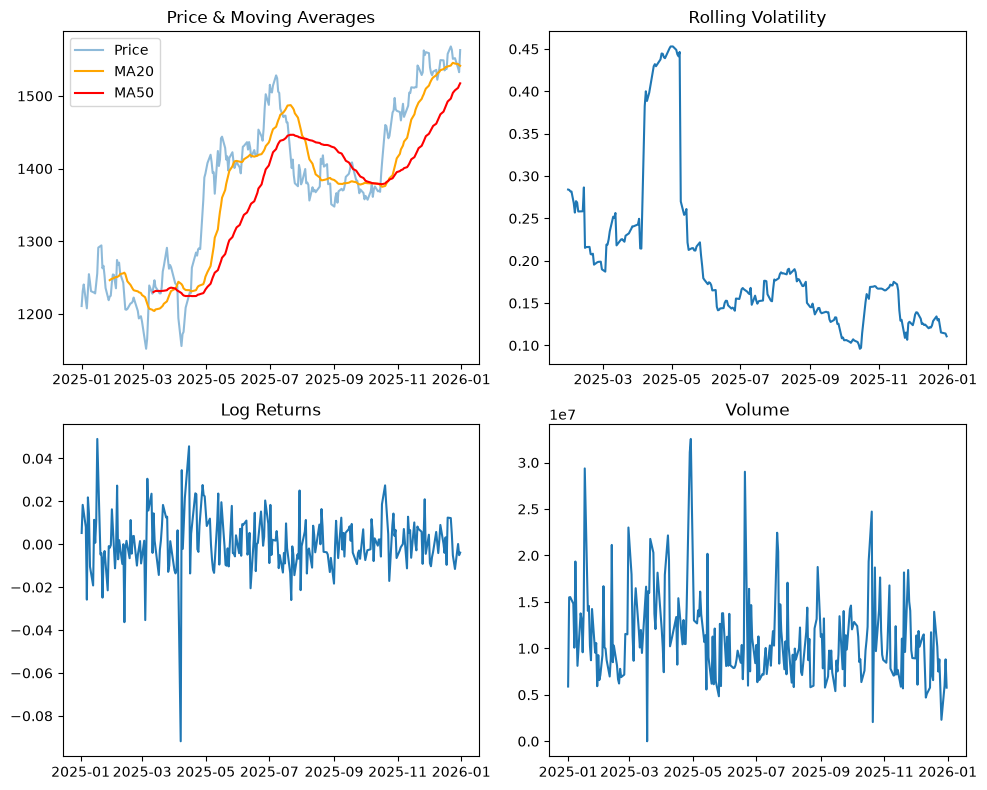

In [42]:
data.dropna()
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(10,8))

ax[0,0].plot(data.index, data['Close'], label='Price', alpha=0.5)
ax[0,0].plot(data.index, data['MA20'], label='MA20', color='orange')
ax[0,0].plot(data.index, data['MA50'], label='MA50', color='red')
ax[0,0].set_title('Price & Moving Averages')
ax[0,0].legend()

ax[0,1].plot(data['rolling_volatility'])
ax[0,1].set_title('Rolling Volatility')

ax[1,0].plot(data['Log Returns'])
ax[1,0].set_title('Log Returns')

ax[1,1].plot(data['Volume'])
ax[1,1].set_title('Volume')

plt.tight_layout()
plt.show()
